<a href="https://colab.research.google.com/github/lolndo/Basic_Networks1/blob/main/%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D1%8B%D0%B9_%D1%81%D0%BB%D0%BE%D0%B9_(Dense)_%D0%94%D0%97_Pro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Задание

Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)


In [ ]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

In [ ]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [ ]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_pro.zip

replace hw_pro/0/1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Путь к директории с базой
base_dir = '/content/hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        else:
            y_train.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (102, 20, 20, 1)
Размер массива y_train (102,)


In [ ]:
# Подготовка данных
from tensorflow.keras.layers import Flatten

# Нормализация пикселей
x_train = x_train.astype('float32') / 255.0

# Преобразуем метки в one-hot (два класса)
y_train_cat = utils.to_categorical(y_train, 2)

# Создаём модель
model = Sequential([
    Flatten(input_shape=(20, 20, 1)),   # 400 входов
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')      # два выхода: крестик / нолик
])

model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Обучаем
history = model.fit(x_train, y_train_cat,
                    batch_size=8,
                    epochs=25,
                    verbose=1)

# Оценка точности на всей обучающей выборке
loss, acc = model.evaluate(x_train, y_train_cat, verbose=1)
print(f'Итоговая точность на обучающей выборке: {acc:.4f} ({acc*100:.1f}%)')

# Проверка требования
if acc > 0.95:
    print("Точность больше 95%")
else:
    print("Точность ниже 95%")




Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5588 - loss: 0.7910
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8529 - loss: 0.4859 
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8137 - loss: 0.3726
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9902 - loss: 0.2253 
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9314 - loss: 0.2132
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9706 - loss: 0.1291 
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0672 
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0518 
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0540 
Epoch 10/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0338 
Epoch 11/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0221 
Epoch 12/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0


Случайный индекс: 24


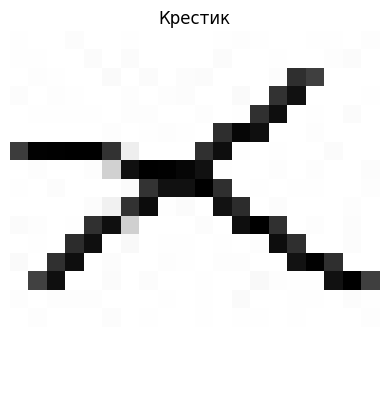

Это: Крестик
Уверенность: 99.33%


In [ ]:
class_names = {0: 'Нолик', 1: 'Крестик'}
x_data=x_train


# 2. Выбираем случайное изображение и ДЕЛАЕМ КОПИЮ
n_rec = np.random.randint(len(x_data))
print(f"\nСлучайный индекс: {n_rec}")

# Берём копию (если x_data нормализован, то и img_copy будет нормализован)
img_copy = x_data[n_rec].copy()  # не меняем x_data/n_rec
img_batch = np.expand_dims(img_copy, axis=0)

# 3. Предсказание
pred = model.predict(img_batch, verbose=0)[0]
pred_class = np.argmax(pred)
confidence = pred[pred_class]

# 4. Визуализация
plt.imshow(img_copy.squeeze(), cmap='gray')
true_label = y_train[n_rec]  # метка всегда в оригинальном y_train
plt.title(class_names[true_label])
plt.axis('off')
plt.show()

print(f"Это: {class_names[pred_class]}")
print(f"Уверенность: {confidence:.2%}")